In [ ]:
import pandas as pd  
import numpy as np 
import matplotlib.pyplot as plt

In [ ]:
url = "../../datasets/train.csv"
data = pd.read_csv(url, index_col="PassengerId")
properties = {"fontsize": 12, "family":"Jetbrains Mono", "weight":"bold", "color":"black"}

In [ ]:
data.info()

# Cleaning the data

In [ ]:
#FILLING MISSING AGES WITH MEAN
data = data.fillna({"Age": data["Age"].mean().round(0)})
# ADDING A NEW COLUMN THAT GROUPUS THE AGES
data["age_group"] = pd.cut(data["Age"], bins=[0,1,5,12,19,39,59,float("inf")], labels=["Infant", "Todller", "Child","Teenager", "Young Adult", "Adult", "Senior"])
data["classes"] = data["Pclass"].map({1:"Upper", 2:"Middle", 3:"Lower"})
data.info()

# Survival Rate Analysis(Age)

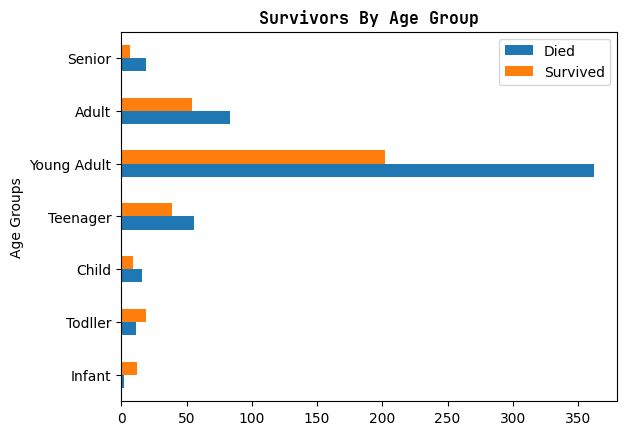

In [25]:
ages = data.groupby("age_group", observed=True)
ages_survivors = ages["Survived"].sum()
ages_total = ages["Survived"].count()
# fig, axes= plt.subplots(1, 2, figsize=(11,5), sharex=True)
# ages_survivors.plot(kind="barh", ax=axes[0])
# ages_total.plot(kind="barh", ax=axes[1])
# axes[0].set_title("Survivors(By Age)", **properties)
# axes[0].set_ylabel("Age Groups")
# axes[1].set_ylabel("Age Groups")
# axes[1].set_title("Total People(By Age)", **properties)
# plt.show()

ages_survivors_cross = pd.crosstab(data.age_group, data.Survived)
ages_survivors_cross.plot(kind="barh")
plt.legend(labels=["Died", "Survived"])
plt.ylabel("Age Groups")
plt.title("Survivors By Age Group", **properties)
plt.show()

In [ ]:
print(f"Total People\n{ages_total}\n")
print(f"Total Survivors\n{ages_survivors}\n")
print(f"Survival Rate{((ages_survivors/ages_total)*100).round(0)}")

**As we can see in the charts and the data**

1. Infants and Toddlers have the highest survival rates, there could be numerous reason for this. However, the most fitting reason could be family protecting the younger ones first and the saying "Women And Children First!"
2. One interesting thing we can observe is, there seems to a high number of young adults who survived. 202 of young adults survived which seems large at first but then you realize there were 564 young adults boarding the ship. This is a classic example of how numbers alone can sometimes be misleading without any context.
3. Surprisingly, only 9 out of 25 children survived which beats my earlier point that children were prioritized. Children in this sense are people aging from 5 to 12 years old. The reason could be that, children are at the age where they are aware of what's happening and that they can possibly die but not mature enough to remain calm. Therefore, making it harder for them to survive.

### Actual Raw Data
**Total People**<br>
_Age group_<br>
Infant          14<br>
Todller         30<br>
Child           25<br>
Teenager        95<br>
Young Adult    564<br>
Adult          137<br>
Senior          26<br>


**Total Survivors**<br>
_Age Group_<br>
Infant          12<br>
Todller         19<br>
Child            9<br>
Teenager        39<br>
Young Adult    202<br>
Adult           54<br>
Senior           7<br>


**Survival Rate**<br>
_Age Group_<br>
Infant         86.0 %<br>
Todller        63.0 %<br>
Child          36.0 %<br>
Teenager       41.0 %<br>
Young Adult    36.0 %<br>
Adult          39.0 %<br>
Senior         27.0 %<br>




# Survivors By Gender

In [27]:
genders = data.groupby("Sex")
gender_survivors = genders["Survived"].sum()
gender_total = genders["Survived"].count()
print(f"Total By Gender\n{gender_total}\n\nSurvivors By Gender\n{gender_survivors}\n\nSurvival Rate\n{((gender_survivors/gender_total)*100).round(1)}")

Total By Gender
Sex
female    314
male      577
Name: Survived, dtype: int64

Survivors By Gender
Sex
female    233
male      109
Name: Survived, dtype: int64

Survival Rate
Sex
female    74.2
male      18.9
Name: Survived, dtype: float64


Text(0.5, 1.0, 'Survivors By Gender')

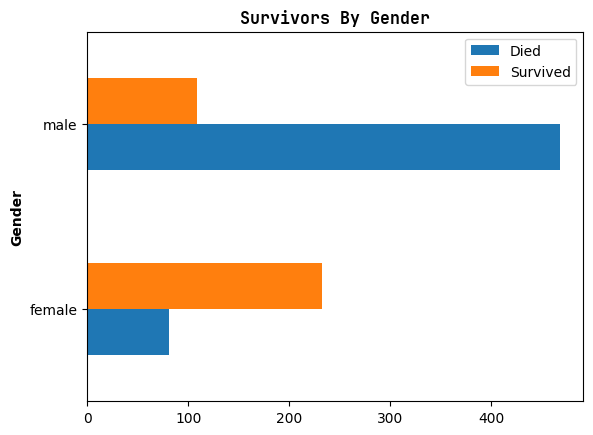

In [26]:
gender_survivors_cross = pd.crosstab(data.Sex, data.Survived)
gender_survivors_cross.plot(kind="barh")
plt.legend(labels=["Died", "Survived"])
plt.ylabel("Gender", fontsize=10, weight="bold")
plt.title("Survivors By Gender", **properties)

**Females survived more than males**<br>
As we can see at first glance, 109 of the males survived while 233 of the females survived. But the shocking part is, even though the males were larger in numbers(577) , the survivors still comprised of mostly females.<br>

If we are talking about proportions then, the **survival rate** of females was **74.2%**, whereas the **survival rate** of males was **18.9%**. This makes the rates even clearer.

There could be various reasons for such a outcome. However, The saying women and children first seems to be more-fitted as per our analysis. However, it could also certainly be true that most of the females were from the age groups that had a high survival rate. Let's dig more.

# Survivors By Class

In [ ]:
classes = data.groupby("classes")
classes_total = classes["Survived"].count()
classes_survivors = classes["Survived"].sum()
print(f"Total By Class\n{classes_total}\n\nSurvivors By Class\n{classes_survivors}\n\nSurvival Rate\n{((classes_survivors/classes_total)*100).round(1)}")

In [ ]:
classes_survivors_cross = pd.crosstab(data.classes, data.Survived)
classes_survivors_cross.plot(kind="barh")
plt.legend(labels=["Died", "Survived"])
plt.ylabel("Class", fontsize=10, weight="bold")
plt.title("Survivors By Class", **properties)
plt.show()

**Upper classes survived the most**<br>
As we can see in the data below, there are few things we found out:<br>

1.) The survival rate of upper class(63%) was almost three times as much as the lower class(24.2%). This shows that as social status increased, the rates of survival also increased.<br>
2.) The middle class had survival rate of 47.3% such that they fall directly in the middle.
3.) The reasons for this disparity could be many, however one I can think of is the upper classes had access to the lower cabins of the ship, thus having high rates of survival.


# Correlation Between Class And Gender
#### The goal is to find out if the presence of a female population affected the survival rates of any of the classes.

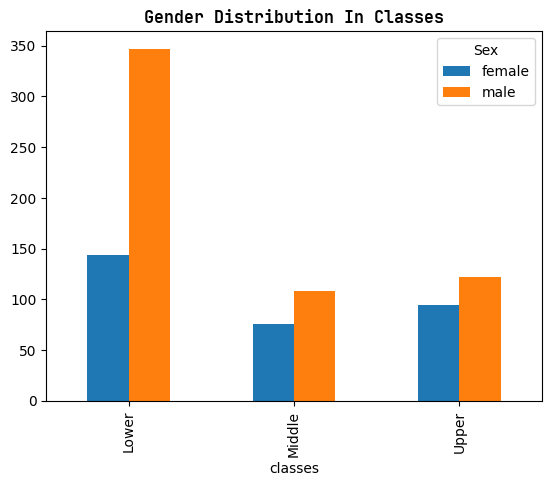

In [24]:
gender_class = pd.crosstab(data.classes, data.Sex)
gender_class.plot(kind="bar")
plt.title('Gender Distribution In Classes', **properties)
plt.show()

**Interesting**<br>
The lower classes comprised of largely males. As we are aware of, males have a less survival rate of only 18.9%. Whereas the upper and middle classes comprised of proportionally more females which could also be the underlying cause of high survival between upper and middle classes.